Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

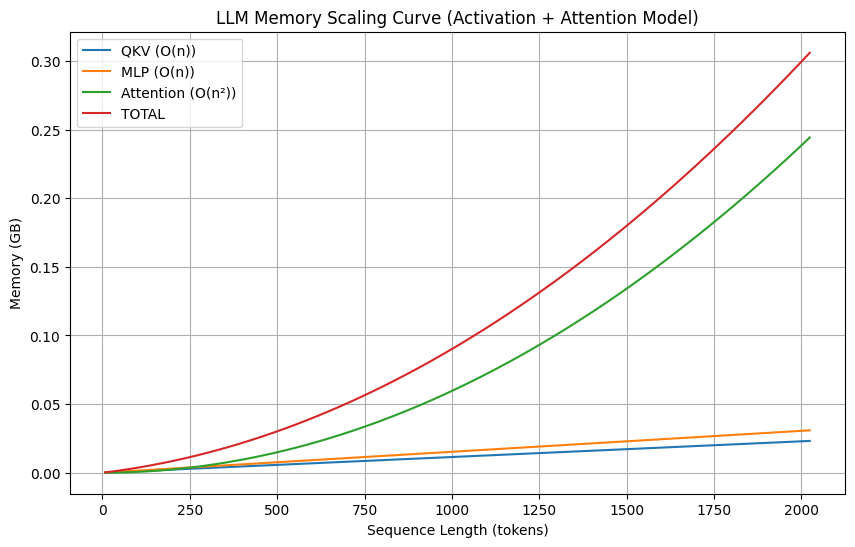

In [22]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ============================================================
# CONFIG
# ============================================================

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DEVICE = "cuda"

# ============================================================
# LOAD MODEL (lightweight)
# ============================================================

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb,
    device_map="auto",
    torch_dtype=torch.float16
)

model.eval()

# ============================================================
# MODEL META
# ============================================================

H = model.config.num_attention_heads
hidden = model.config.hidden_size
bytes_per_elem = 2  # fp16

B = 1

# ============================================================
# MEMORY MODEL
# ============================================================

def memory_estimate(T):

    # QKV (linear)
    mem_qkv = 3 * B * T * hidden * bytes_per_elem

    # MLP (linear)
    mem_mlp = B * T * (4 * hidden) * bytes_per_elem

    # Attention matrix (quadratic)
    mem_attn = B * H * T * T * bytes_per_elem

    # Output residual
    mem_out = B * T * hidden * bytes_per_elem

    total = mem_qkv + mem_mlp + mem_attn + mem_out

    return (
        mem_qkv / (1024**3),
        mem_mlp / (1024**3),
        mem_attn / (1024**3),
        total / (1024**3)
    )

# ============================================================
# SCALING EXPERIMENT
# ============================================================

seq_lengths = list(range(8, 2049, 32))

qkv_curve = []
mlp_curve = []
attn_curve = []
total_curve = []

for T in seq_lengths:

    qkv, mlp, attn, total = memory_estimate(T)

    qkv_curve.append(qkv)
    mlp_curve.append(mlp)
    attn_curve.append(attn)
    total_curve.append(total)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(seq_lengths, qkv_curve, label="QKV (O(n))")
plt.plot(seq_lengths, mlp_curve, label="MLP (O(n))")
plt.plot(seq_lengths, attn_curve, label="Attention (O(n²))")
plt.plot(seq_lengths, total_curve, label="TOTAL")

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Memory (GB)")
plt.title("LLM Memory Scaling Curve (Activation + Attention Model)")
plt.legend()
plt.grid(True)

plt.show()